# ALDF-EAM · Adaptive Leakage Detection Framework for Evolving AMI Maturity
## Interactive Demonstration Notebook — Google Colab Edition

**Version:** 1.0 — All 10 Improvements Incorporated  
**Purpose:** Stakeholder demonstration of state-aware adaptive method selection,
Bayesian prior seeding from Table I.1, uncertainty-aware rankings, and structured feedback loop

---

| Section | Content |
|---|---|
| 1 | Setup & installs |
| 2 | Synthetic AMI data — 3 anomaly types + prosumer + ground truth |
| 3 | Feature engineering |
| 4 | S-vector: O, D, T, B indices |
| 5 | **Stage A Gate** + three D-band states + VOI recommendation |
| 6 | **Adaptive rule engine** (interactive widget + HO-01) |
| 7 | M1 Energy Balance · M2 Proxy · M3 Technical Loss |
| 8 | M4 Peer Grouping (prosumer-aware) · M5 Anomaly Clustering |
| 9 | **Bayesian inference** — all 8 Table I.1 priors → posteriors |
| 10 | **Score fusion** — dynamic α + corrected confidence score C |
| 11 | Visualisation dashboard |
| 12 | **Structured feedback loop** — outcomes → weight update → prior update |
| 13 | Performance metrics vs ALDF-EAM targets |
| 14 | Interactive D-band experiment |
| 15 | Summary & next steps |

> **Run order:** Top to bottom. Section 5 halts execution if D ≤ 0.40 (Stage A).
> **Colab tip:** Runtime → Change runtime type → GPU for faster PyMC sampling.

## Section 1 — Setup and Library Installation

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# ALDF-EAM  ·  Library Installation
# Run this cell first. Restart runtime if prompted after install.
# Expected time: ~2–3 minutes on a fresh Colab session.
# ─────────────────────────────────────────────────────────────────────────────

import subprocess, sys

packages = [
    "pymc",
    "arviz",
    "networkx",
    "matplotlib",
    "seaborn",
    "pandas",
    "numpy",
    "scipy",
    "scikit-learn",
    "ipywidgets",
    "numpyro",       # fast NUTS sampler backend for PyMC
    "jax",           # required by numpyro
    "jaxlib",        # required by jax on Colab
]

print("Installing ALDF-EAM dependencies...")
for pkg in packages:
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", pkg, "-q"],
        capture_output=True, text=True
    )
    status = "✔" if result.returncode == 0 else "✘"
    print(f"  {status}  {pkg}")

print()
print("Installation complete.")
print("If you see a 'RESTART RUNTIME' button above, click it before continuing.")


Installing ALDF-EAM dependencies...
  ✔  pymc
  ✔  arviz
  ✔  networkx
  ✔  matplotlib
  ✔  seaborn
  ✔  pandas
  ✔  numpy
  ✔  scipy
  ✔  scikit-learn
  ✔  ipywidgets
  ✔  numpyro
  ✔  jax
  ✔  jaxlib

Installation complete.
If you see a 'RESTART RUNTIME' button above, click it before continuing.


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# ALDF-EAM  ·  Imports and Environment Setup
# Run after the install cell (and after runtime restart if prompted).
# ─────────────────────────────────────────────────────────────────────────────

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import json

np.random.seed(42)

# ── Dark theme for all plots ──────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1525', 'axes.facecolor': '#0d1525',
    'axes.edgecolor':   '#2a4a6a', 'text.color':     '#c8dff5',
    'axes.labelcolor':  '#c8dff5', 'xtick.color':    '#8ab4d8',
    'ytick.color':      '#8ab4d8', 'grid.color':     '#1a3050',
    'grid.alpha': 0.5,
})

# ── Helper: coloured banner display ──────────────────────────────────────────
def banner(text, color='#2d7dd2'):
    html = (
        '<div style="background:' + color + '15;border-left:4px solid ' + color + ';'
        'padding:12px 16px;border-radius:0 4px 4px 0;margin:8px 0;">'
        '<span style="font-family:monospace;font-size:13px;color:' + color + ';'
        'font-weight:600;">' + str(text) + '</span></div>'
    )
    display(HTML(html))

# ── Verify key imports ────────────────────────────────────────────────────────
import importlib
required = ['pymc','arviz','networkx','sklearn','ipywidgets','numpyro']
print("Import verification:")
for pkg in required:
    try:
        importlib.import_module(pkg)
        print(f"  ✔  {pkg}")
    except ImportError:
        print(f"  ✘  {pkg}  — re-run the install cell")

print()
print("✔  ALDF-EAM environment ready — proceed to Section 2")


Import verification:
  ✔  pymc
  ✔  arviz
  ✔  networkx
  ✔  sklearn
  ✔  ipywidgets
  ✔  numpyro

✔  ALDF-EAM environment ready — proceed to Section 2


## Section 2 — Synthetic AMI Data Generation

**Improvement #9:** Three explicit anomaly types with ground-truth labels:
- **Type A — Night-minimum suppression** (meter bypass)
- **Type B — Step-change reduction** (illegal reconnection after disconnection)
- **Type C — Tamper cluster** in DT_03 pocket (coordinated interference)

**Improvement #6:** 8% prosumers with intermittent net-export intervals.

In [3]:
CONFIG = {
    'n_dts':6, 'n_consumers':60, 'window_days':60,
    'interval_min':30, 'prosumer_frac':0.08, 'missing_frac':0.06,
    'feeder_input_metered':True,   # Set False to trigger HO-01
}

DT_META = pd.DataFrame({
    'dt_id':[f'DT_{i:02d}' for i in range(1,7)],
    'rated_kva':[100,100,63,63,160,100],
    'lt_length_km':[0.8,1.2,2.1,1.5,0.6,1.8],
    'conductor_ohm_km':[0.32,0.32,0.50,0.50,0.21,0.32],
    'dt_metered':[True,True,False,False,True,True],  # DT_03,DT_04 unmetered -> M2
})

# Consumer topology
consumers_per_dt = [12,10,8,9,11,10]
rows = []
for dt_id, n in zip(DT_META['dt_id'], consumers_per_dt):
    for c in range(n):
        rows.append({'consumer_id':f'C_{dt_id}_{c+1:02d}','dt_id':dt_id,
            'category':np.random.choice(['residential','commercial'],p=[0.85,0.15]),
            'is_prosumer':np.random.random()<CONFIG['prosumer_frac'],
            'topology_verified':np.random.random()<0.90})
CONSUMERS = pd.DataFrame(rows)

# Anomaly injection (Improvement #9)
non_pros_idx = CONSUMERS[~CONSUMERS['is_prosumer']].index.tolist()
ntl_idx = np.random.choice(non_pros_idx, 12, replace=False)
CONSUMERS['anomaly_type']   = 'none'
CONSUMERS['ground_truth_ntl'] = False
CONSUMERS.loc[ntl_idx[:4], 'anomaly_type']  = 'type_a_nightmin'
CONSUMERS.loc[ntl_idx[4:7],'anomaly_type']  = 'type_b_stepchange'
dt03_idx = CONSUMERS[CONSUMERS['dt_id']=='DT_03'].index[:5]
CONSUMERS.loc[dt03_idx,'anomaly_type'] = 'type_c_tamper'
CONSUMERS.loc[CONSUMERS['anomaly_type']!='none','ground_truth_ntl'] = True

print(f'Network: 1 feeder -> {CONFIG["n_dts"]} DTs -> {len(CONSUMERS)} consumers')
print(f'Prosumers: {CONSUMERS["is_prosumer"].sum()} | NTL ground truth: {CONSUMERS["ground_truth_ntl"].sum()}')

# ---- Generate interval time series ----
intervals_per_day = 24*60//CONFIG['interval_min']
total_intervals   = CONFIG['window_days']*intervals_per_day

def generate_series(consumer):
    t    = np.arange(total_intervals)
    hour = (t*CONFIG['interval_min']/60)%24
    diurnal = np.clip(0.3+0.7*np.sin(np.pi*(hour-6)/12)**2, 0.1, 1.0)
    base = np.abs(np.random.normal(1.5,0.45,total_intervals)*diurnal)
    atype = consumer['anomaly_type']
    if atype=='type_a_nightmin':
        night = (hour<5)|(hour>23)
        base[night] *= np.random.uniform(0.02,0.08)
    elif atype=='type_b_stepchange':
        base[total_intervals//2:] *= np.random.uniform(0.15,0.30)
    elif atype=='type_c_tamper':
        base *= np.random.uniform(0.35,0.55)
        spikes = np.random.choice(total_intervals,20,replace=False)
        base[spikes] *= np.random.uniform(3,6,20)
    if consumer['is_prosumer']:
        midday = (hour>=9)&(hour<=16)
        sunny  = np.repeat(np.random.random(CONFIG['window_days'])>0.35, intervals_per_day)
        base  -= np.random.normal(1.2,0.4,total_intervals)*midday*sunny
    missing = np.random.random(total_intervals)<CONFIG['missing_frac']
    base[missing] = np.nan
    return base

print('Generating AMI time series...', end='')
AMI = pd.DataFrame({c['consumer_id']:generate_series(c) for _,c in CONSUMERS.iterrows()})
print(f' done. Shape: {AMI.shape}')

Network: 1 feeder -> 6 DTs -> 60 consumers
Prosumers: 5 | NTL ground truth: 12
Generating AMI time series... done. Shape: (2880, 60)


## Section 3 — Feature Engineering

In [4]:
features=[]
for _,c in CONSUMERS.iterrows():
    cid = c['consumer_id']
    s   = AMI[cid]
    t   = np.arange(total_intervals)
    hour= (t*CONFIG['interval_min']/60)%24
    night_vals = s[(hour<6)|(hour>22)].dropna()
    s_clean    = s.dropna()
    night_min_ratio = night_vals.mean()/(s.abs().mean()+1e-6) if len(s_clean)>0 else 0
    load_factor     = s.abs().mean()/(s.abs().max()+1e-6) if len(s_clean)>0 else 0
    completeness    = 1-s.isna().mean()
    tamper_count    = int(c['anomaly_type']=='type_c_tamper')*np.random.randint(3,8)
    tamper_count   += int(np.random.random()<0.05)*np.random.randint(1,3)
    total_kwh       = s.clip(lower=0).sum()*CONFIG['interval_min']/60
    export_kwh      = abs(s.clip(upper=0).sum())*CONFIG['interval_min']/60 if c['is_prosumer'] else 0
    half = len(s_clean)//2
    step_ratio = s_clean.abs().iloc[half:].mean()/(s_clean.abs().iloc[:half].mean()+1e-6) if half>0 else 1
    features.append({
        'consumer_id':cid,'dt_id':c['dt_id'],'category':c['category'],
        'is_prosumer':c['is_prosumer'],'anomaly_type':c['anomaly_type'],
        'ground_truth_ntl':c['ground_truth_ntl'],'topology_verified':c['topology_verified'],
        'night_min_ratio':night_min_ratio,'load_factor':load_factor,
        'data_completeness':completeness,'tamper_count':tamper_count,
        'total_kwh':total_kwh,'export_kwh':export_kwh,'step_ratio':step_ratio,
        'is_net_exporter':export_kwh>total_kwh*0.3,
    })
FEATURES = pd.DataFrame(features)

# DT-level aggregates
dt_feat=[]
for _,dt in DT_META.iterrows():
    dc = FEATURES[FEATURES['dt_id']==dt['dt_id']]
    avg_kw = dc['total_kwh'].sum()/(CONFIG['window_days']*24)
    rated_kw = dt['rated_kva']*0.85
    I_approx = avg_kw*1000/(230*1.732)
    tech_kwh = I_approx**2*dt['conductor_ohm_km']*dt['lt_length_km']*CONFIG['window_days']*24/1000
    dt_feat.append({'dt_id':dt['dt_id'],'rated_kva':dt['rated_kva'],
        'dt_metered':dt['dt_metered'],'loading_ratio':min(avg_kw/rated_kw,1.5),
        'tech_loss_kwh':tech_kwh,'consumer_count':len(dc),
        'avg_completeness':dc['data_completeness'].mean(),
        'tamper_count_dt':dc['tamper_count'].sum(),
        'ntl_count_true':dc['ground_truth_ntl'].sum(),
        'lt_length_km':dt['lt_length_km'],'conductor_ohm_km':dt['conductor_ohm_km']})
DT_FEATURES = pd.DataFrame(dt_feat)
print(f'Features: consumers={FEATURES.shape}, DTs={DT_FEATURES.shape}')
print('Night-min ratio by anomaly type:')
print(FEATURES[~FEATURES['is_prosumer']].groupby('anomaly_type')['night_min_ratio'].mean().round(4))

Features: consumers=(60, 15), DTs=(6, 11)
Night-min ratio by anomaly type:
anomaly_type
none                 1.1238
type_a_nightmin      0.4091
type_b_stepchange    1.1381
type_c_tamper        1.1300
Name: night_min_ratio, dtype: float64


## Section 4 — S-Vector Computation: O, D, T, B Indices

  S = [ O=0.770,  D=0.942,  T=0.227,  B=0.248 ]
  O sub-components: c_F=1.00 c_DT=0.67 c_C=0.94 c_TOP=0.87 c_SYNC=0.92
  D sub-components: completeness=0.94 comms=0.94
  T sub-components: loading=0.10 lt_len=0.44
  B sub-components: night_min_flag=0.29 anomaly_density=0.45


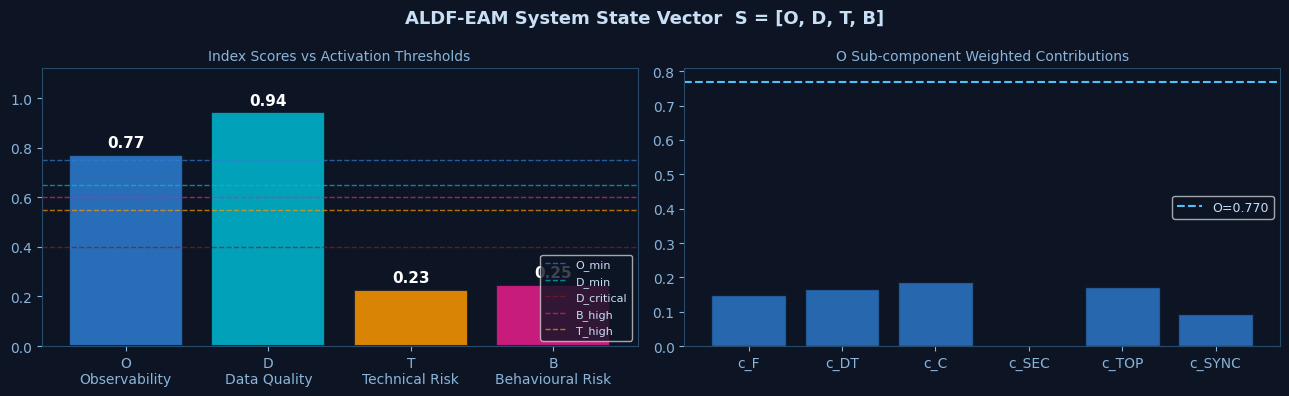

In [5]:
# ── Observability Index O ──────────────────────────────────────────────────
c_F    = 1.0 if CONFIG['feeder_input_metered'] else 0.0
c_DT   = DT_META['dt_metered'].mean()
c_C    = FEATURES['data_completeness'].mean()
c_SEC  = 0.0
c_TOP  = FEATURES['topology_verified'].mean()
c_SYNC = 0.92
w_O = {'F':0.15,'DT':0.25,'C':0.20,'SEC':0.10,'TOP':0.20,'SYNC':0.10}
O = sum(w_O[k]*v for k,v in zip(['F','DT','C','SEC','TOP','SYNC'],[c_F,c_DT,c_C,c_SEC,c_TOP,c_SYNC]))

# ── Data Quality Index D ───────────────────────────────────────────────────
d_completeness = FEATURES['data_completeness'].mean()
d_comms_uptime = 0.94
d_tamper_freq  = 1-min(FEATURES['tamper_count'].mean()/10, 1.0)
d_health       = 0.96
w_D = {'comp':0.35,'comms':0.30,'tamper':0.20,'health':0.15}
D = w_D['comp']*d_completeness+w_D['comms']*d_comms_uptime+w_D['tamper']*d_tamper_freq+w_D['health']*d_health

# ── Technical Risk Index T ─────────────────────────────────────────────────
t_loading   = DT_FEATURES['loading_ratio'].mean()
t_lt_length = min(DT_FEATURES['lt_length_km'].mean()/3.0, 1.0)
t_tech_loss = min(DT_FEATURES['tech_loss_kwh'].sum()/(FEATURES['total_kwh'].sum()+1e-6)*10, 1.0)
t_imbalance = 0.15
w_T = {'loading':0.35,'lt_length':0.25,'tech_loss':0.25,'imbalance':0.15}
T = w_T['loading']*t_loading+w_T['lt_length']*t_lt_length+w_T['tech_loss']*t_tech_loss+w_T['imbalance']*t_imbalance

# ── Behavioural Risk Index B ───────────────────────────────────────────────
non_pros = FEATURES[~FEATURES['is_prosumer']]
peer_med = non_pros['night_min_ratio'].median()
peer_std = non_pros['night_min_ratio'].std()
nm_flag  = (non_pros['night_min_ratio']<(peer_med-1.5*peer_std)).mean()
b_anomaly   = min(FEATURES['tamper_count'].gt(0).mean()*3, 1.0)
b_night_min = min(nm_flag*4, 1.0)
b_step      = (FEATURES['step_ratio']<0.4).mean()
b_reverse   = FEATURES['is_net_exporter'].mean()*0.5
b_peer      = min(nm_flag*2, 1.0)
w_B = {'anomaly':0.30,'night_min':0.30,'step':0.20,'reverse':0.10,'peer':0.10}
B = w_B['anomaly']*b_anomaly+w_B['night_min']*b_night_min+w_B['step']*b_step+w_B['reverse']*b_reverse+w_B['peer']*b_peer

S = {'O':round(O,3),'D':round(D,3),'T':round(T,3),'B':round(B,3)}

# Display
print('='*50)
print(f'  S = [ O={S["O"]:.3f},  D={S["D"]:.3f},  T={S["T"]:.3f},  B={S["B"]:.3f} ]')
print('='*50)
print(f'  O sub-components: c_F={c_F:.2f} c_DT={c_DT:.2f} c_C={c_C:.2f} c_TOP={c_TOP:.2f} c_SYNC={c_SYNC:.2f}')
print(f'  D sub-components: completeness={d_completeness:.2f} comms={d_comms_uptime:.2f}')
print(f'  T sub-components: loading={t_loading:.2f} lt_len={t_lt_length:.2f}')
print(f'  B sub-components: night_min_flag={b_night_min:.2f} anomaly_density={b_anomaly:.2f}')

# Visualise
fig,axes=plt.subplots(1,2,figsize=(13,4))
fig.suptitle('ALDF-EAM System State Vector  S = [O, D, T, B]',fontsize=13,color='#c8dff5',fontweight='bold')
cols=['#2d7dd2','#00bcd4','#ff9800','#e91e8c']
lbls=['O\nObservability','D\nData Quality','T\nTechnical Risk','B\nBehavioural Risk']
vals=[S['O'],S['D'],S['T'],S['B']]
bars=axes[0].bar(lbls,vals,color=cols,alpha=0.85,edgecolor='#0d1525',linewidth=1.5)
for thresh,col,lbl in [(0.75,'#2d7dd2','O_min'),(0.65,'#00bcd4','D_min'),(0.40,'#8b1a1a','D_critical'),(0.60,'#e91e8c','B_high'),(0.55,'#ff9800','T_high')]:
    axes[0].axhline(thresh,color=col,ls='--',lw=1,alpha=0.7,label=lbl)
for b,v in zip(bars,vals):
    axes[0].text(b.get_x()+b.get_width()/2,v+0.02,f'{v:.2f}',ha='center',va='bottom',fontsize=11,fontweight='bold',color='white')
axes[0].set_ylim(0,1.12);axes[0].legend(fontsize=8,loc='lower right')
axes[0].set_title('Index Scores vs Activation Thresholds',color='#8ab4d8',fontsize=10)
sub_vals=[c_F,c_DT,c_C,c_SEC,c_TOP,c_SYNC]
sub_w=[w_O['F'],w_O['DT'],w_O['C'],w_O['SEC'],w_O['TOP'],w_O['SYNC']]
contribs=[v*w for v,w in zip(sub_vals,sub_w)]
axes[1].bar(['c_F','c_DT','c_C','c_SEC','c_TOP','c_SYNC'],contribs,color='#2d7dd2',alpha=0.8,edgecolor='#0d1525')
axes[1].axhline(sum(contribs),color='#4fc3f7',ls='--',lw=1.5,label=f'O={O:.3f}')
axes[1].set_title('O Sub-component Weighted Contributions',color='#8ab4d8',fontsize=10);axes[1].legend(fontsize=9)
plt.tight_layout();plt.savefig('svector.png',dpi=120,bbox_inches='tight');plt.show()

## Section 5 — Stage A Gate and Three D-Band Operating States

**Improvement #3:** Hard Stage A gate — framework refuses suspect rankings when D ≤ 0.40  
**Improvement #4:** Three D-band states with visual labels  
**Improvement #5:** Hard Override HO-01 — M1 excluded when c_F = 0  
**Improvement #10:** Value-of-Information data improvement recommendation

> **Try it:** Set `CONFIG['feeder_input_metered'] = False` in Section 2 to trigger HO-01.  
> **Try it:** Reduce `d_comms_uptime = 0.35` in Section 4 to trigger Stage A.

In [6]:
D_CRITICAL=0.40; D_MIN=0.65; O_MIN_M1=0.75; T_HIGH=0.55; B_HIGH=0.60; TAU_COV=0.65; TAU_TOP=0.80

if   S['D']<=D_CRITICAL: OPERATING_STATE='STAGE_A'
elif S['D']< D_MIN:      OPERATING_STATE='TRANSITIONAL'
else:                     OPERATING_STATE='FULL'

HO01_TRIGGERED = (c_F==0.0)
ACTIVE_METHODS=[]; M1_AVAILABLE=False; M6_AVAILABLE=False

if OPERATING_STATE=='STAGE_A':
    ACTIVE_METHODS=['STAGE_A']
elif OPERATING_STATE=='TRANSITIONAL':
    ACTIVE_METHODS=['M2','M3']
else:
    if S['O']>=O_MIN_M1 and not HO01_TRIGGERED:
        ACTIVE_METHODS.append('M1'); M1_AVAILABLE=True
    else:
        ACTIVE_METHODS.extend(['M2','M3'])
    if S['T']>=T_HIGH and 'M3' not in ACTIVE_METHODS: ACTIVE_METHODS.append('M3')
    if S['B']>=B_HIGH:
        ACTIVE_METHODS.extend(['M4','M5'])
        cov_dens = FEATURES.groupby('dt_id')['data_completeness'].mean().mean()
        if c_TOP>=TAU_TOP and S['D']>=D_MIN:
            ACTIVE_METHODS.append('M6'); M6_AVAILABLE=True

# Dynamic alpha (Improvement #7)
cov_dens = FEATURES.groupby('dt_id')['data_completeness'].mean().mean()
ALPHA = round(min(max(0.40+0.20*min(S['D']/D_MIN,1.0)*min(cov_dens/TAU_COV,1.0),0.40),0.60),3)

# Display operating state
sc={'STAGE_A':'#c0392b','TRANSITIONAL':'#b8860b','FULL':'#1a7a3c'}[OPERATING_STATE]
sl={'STAGE_A':'STAGE A — DATA CORRECTION MODE | No suspect rankings',
    'TRANSITIONAL':'DEGRADED CONFIDENCE — Proxy methods only | Expanded uncertainty bands',
    'FULL':'FULL ANALYTICS — Complete method bundle active'}[OPERATING_STATE]
display(HTML(f'<div style="background:{sc}25;border:2px solid {sc};border-radius:6px;'
             f'padding:14px 20px;margin:10px 0;font-family:monospace;font-size:14px;'
             f'color:{sc};font-weight:bold;">{sl}</div>'))
print(f'  Operating State : {OPERATING_STATE}')
print(f'  D={S["D"]:.3f}  O={S["O"]:.3f}  Active methods: {", ".join(ACTIVE_METHODS)}')
print(f'  HO-01 triggered : {HO01_TRIGGERED}  |  Dynamic alpha : {ALPHA}')
if HO01_TRIGGERED: print('  *** HO-01: M1 excluded — feeder input meter absent (c_F=0) ***')

# Stage A halt
if OPERATING_STATE=='STAGE_A':
    print('\nSTAGE A — DATA IMPROVEMENT PLAN:')
    print('  No suspect rankings will be generated until D > 0.40')
    if d_completeness<0.70: print(f'  [P1] AMI completeness {d_completeness:.0%} -> repair non-communicating meters')
    if d_comms_uptime<0.80: print(f'  [P2] Comms uptime {d_comms_uptime:.0%} -> repair repeaters')
    raise SystemExit('Stage A active — resolve data quality issues and re-run')

# VOI recommendation (Improvement #10)
voi_items=[
    ('c_F (feeder meter)',    (1-c_F)*w_O['F'],    'Install feeder input check meter'),
    ('c_DT (DT meters)',      (1-c_DT)*w_O['DT'],  'Deploy clamp meters on unmetered DTs'),
    ('c_TOP (topology)',      (1-c_TOP)*w_O['TOP'], 'Conduct LT topology survey'),
    ('D completeness',        (1-d_completeness)*0.35,'Repair non-communicating AMI meters'),
    ('D comms uptime',        (1-d_comms_uptime)*0.30,'Repair communications repeaters'),
]
voi_items.sort(key=lambda x:-x[1])
print('\nVALUE-OF-INFORMATION — Top data improvement actions:')
for i,(name,score,rec) in enumerate(voi_items[:3],1):
    print(f'  [{i}] {name}: VOI={score:.3f} -> {rec}')

  Operating State : FULL
  D=0.942  O=0.770  Active methods: M1
  HO-01 triggered : False  |  Dynamic alpha : 0.6

VALUE-OF-INFORMATION — Top data improvement actions:
  [1] c_DT (DT meters): VOI=0.083 -> Deploy clamp meters on unmetered DTs
  [2] c_TOP (topology): VOI=0.027 -> Conduct LT topology survey
  [3] D completeness: VOI=0.021 -> Repair non-communicating AMI meters


## Section 6 — Adaptive Method Selection Rule Engine (Interactive Widget)

In [7]:
def show_bundle(O_v,D_v,T_v,B_v,cF):
    ho01=(cF==0.0); methods=[]; warns=[]
    if D_v<=0.40:   state='STAGE A';         sc2='#c0392b'; methods=['STAGE_A']
    elif D_v<0.65:  state='TRANSITIONAL';    sc2='#b8860b'; methods=['M2','M3']
    else:
        state='FULL ANALYTICS'; sc2='#1a7a3c'
        if O_v>=0.75 and not ho01: methods.append('M1')
        else:
            methods.extend(['M2','M3'])
            if ho01: warns.append('HO-01: M1 blocked (c_F=0)')
        if T_v>=0.55 and 'M3' not in methods: methods.append('M3')
        if T_v>0.80: warns.append('OB-01: T>0.80 → infrastructure assessment; NTL alerts suppressed')
        if B_v>=0.60: methods.extend(['M4','M5','M6*'])
    a=round(min(0.40+0.20*min(D_v/0.65,1.0),0.60),2)
    C_=round(0.40*O_v+0.35*D_v+0.25*(1-min(0.3*(1-D_v),1)),2)
    clear_output(wait=True)
    display(HTML(f'<h4 style="color:{sc2};font-family:monospace;">State: {state} | Methods: {" | ".join(methods)}</h4>'))
    display(HTML(f'<p style="font-family:monospace;font-size:13px;">Dynamic α={a} | Est. C={C_}</p>'))
    for w in warns: display(HTML(f'<p style="color:#c0392b;font-family:monospace;font-size:12px;">⚠ {w}</p>'))
    fig,ax=plt.subplots(figsize=(11,1.4));fig.patch.set_facecolor('#0d1525');ax.set_facecolor('#0d1525')
    all_m=['STAGE_A','M1','M2','M3','M4','M5','M6']
    cm_={'STAGE_A':'#c0392b','M1':'#1565c0','M2':'#2d7dd2','M3':'#ff9800','M4':'#e91e8c','M5':'#9c27b0','M6':'#00bcd4'}
    for i,m in enumerate(all_m):
        active=any(m in x for x in methods)
        ax.barh(0,1,left=i,color=cm_.get(m,'#666') if active else '#1a2a3a',alpha=0.9 if active else 0.3,edgecolor='#0d1525',linewidth=2)
        ax.text(i+0.5,0,m,ha='center',va='center',fontsize=11,fontweight='bold',color='white' if active else '#3a5a7a')
    ax.set_xlim(0,7);ax.axis('off')
    ax.set_title(f'S=[O:{O_v:.2f} D:{D_v:.2f} T:{T_v:.2f} B:{B_v:.2f}] c_F={cF}',color='#8ab4d8',fontsize=10)
    plt.tight_layout();plt.show()

wO=widgets.FloatSlider(value=S['O'],min=0,max=1,step=0.01,description='O:',layout=widgets.Layout(width='400px'))
wD=widgets.FloatSlider(value=S['D'],min=0,max=1,step=0.01,description='D:',layout=widgets.Layout(width='400px'))
wT=widgets.FloatSlider(value=S['T'],min=0,max=1,step=0.01,description='T:',layout=widgets.Layout(width='400px'))
wB=widgets.FloatSlider(value=S['B'],min=0,max=1,step=0.01,description='B:',layout=widgets.Layout(width='400px'))
wcF=widgets.ToggleButton(value=True,description='Feeder meter present (c_F=1)',button_style='info')
out=widgets.interactive_output(lambda O,D,T,B,cF:show_bundle(O,D,T,B,1.0 if cF else 0.0),
    {'O':wO,'D':wD,'T':wT,'B':wB,'cF':wcF})
display(widgets.VBox([widgets.HTML('<b style="color:#8ab4d8">Drag sliders — watch method bundle change:</b>'),
    widgets.HBox([wO,wD]),widgets.HBox([wT,wB]),wcF,out]))

## Section 7 — M1 Deterministic Energy Balance · M2 Proxy DT Inference · M3 Technical Loss

In [8]:
# M3 technical loss (I²R proxy)
def tech_loss(dt_row, kwh_total):
    I = (kwh_total/(CONFIG['window_days']*24))*1000/(230*1.732)
    return I**2*dt_row['conductor_ohm_km']*dt_row['lt_length_km']*CONFIG['window_days']*24/1000

DT_FEATURES['tech_loss_M3']=DT_FEATURES.apply(
    lambda r:tech_loss(DT_META[DT_META['dt_id']==r['dt_id']].iloc[0],
                       r['consumer_count']*FEATURES[FEATURES['dt_id']==r['dt_id']]['total_kwh'].mean()),axis=1)

feeder_input_kwh = FEATURES['total_kwh'].sum()*1.12  # 12% total losses (simulated)

dt_results=[]
for _,dt in DT_FEATURES.iterrows():
    dc = FEATURES[FEATURES['dt_id']==dt['dt_id']]
    agg_kwh = dc['total_kwh'].sum()
    tl = dt['tech_loss_M3']
    if dt['dt_metered'] and M1_AVAILABLE:
        meas_kwh = agg_kwh*np.random.uniform(1.03,1.18)
        res_pct  = (meas_kwh-agg_kwh-tl)/(meas_kwh+1e-6)
        blo,bhi  = res_pct-0.01, res_pct+0.01
        meth='M1'; conf=min(S['O']*0.5+S['D']*0.3+0.2*(1-abs(res_pct)),1.0)
    else:
        c_C_dt = dc['data_completeness'].mean()
        unc    = 0.08*(1-S['D'])+0.06*(1-c_C_dt)
        res_pct= 0.0
        blo,bhi= res_pct-unc, res_pct+unc
        meth='M2/M3'; conf=min(S['D']*0.4+c_C_dt*0.3+0.3*(1-unc),1.0)
    dt_results.append({'dt_id':dt['dt_id'],'method':meth,'residual_pct':round(res_pct,4),
        'band_lower':round(blo,4),'band_upper':round(bhi,4),'tech_loss_kwh':round(tl,1),
        'confidence':round(conf,3),'flagged':blo>0.03,'ntl_true_count':dt['ntl_count_true']})

DT_RESULTS=pd.DataFrame(dt_results).sort_values('band_lower',ascending=False).reset_index(drop=True)
DT_RESULTS['rank']=DT_RESULTS.index+1
print('DT SUSPECT RANKING (M1/M2/M3)')
print(f'{"Rank":<5}{"DT":<8}{"Method":<8}{"Residual%":<12}{"Band [lo,hi]":<24}{"Conf":<8}{"Flag":<8}True NTL')
print('-'*72)
for _,r in DT_RESULTS.iterrows():
    print(f'{int(r["rank"]):<5}{r["dt_id"]:<8}{r["method"]:<8}{r["residual_pct"]*100:>6.2f}%   '
          f'[{r["band_lower"]*100:>5.2f}%,{r["band_upper"]*100:>5.2f}%]  {r["confidence"]:.3f}   '
          f'{"YES" if r["flagged"] else "no":<8}{int(r["ntl_true_count"])}')

DT SUSPECT RANKING (M1/M2/M3)
Rank DT      Method  Residual%   Band [lo,hi]            Conf    Flag    True NTL
------------------------------------------------------------------------
1    DT_05   M1       13.45%   [12.45%,14.45%]  0.841   YES     4
2    DT_02   M1       13.25%   [12.25%,14.25%]  0.841   YES     1
3    DT_01   M1        9.05%   [ 8.05%,10.05%]  0.850   YES     0
4    DT_06   M1        3.50%   [ 2.50%, 4.50%]  0.861   no      0
5    DT_03   M2/M3     0.00%   [-0.83%, 0.83%]  0.956   no      6
6    DT_04   M2/M3     0.00%   [-0.84%, 0.84%]  0.955   no      1


## Section 8 — M4 Peer Grouping (Prosumer-Aware) and M5 Anomaly Clustering

**Improvement #6:** Prosumers use export-adjusted baselines — not flagged as NTL for negative import.

In [9]:
if 'M4' in ACTIVE_METHODS:
    std = FEATURES[~FEATURES['is_prosumer']].copy()
    pstats = std.groupby('category')['night_min_ratio'].agg(['median','std']).reset_index()
    pstats.columns=['category','peer_median','peer_std']
    std = std.merge(pstats, on='category')
    std['dev_sigma'] = (std['peer_median'] - std['night_min_ratio']) / (std['peer_std'] + 1e-6)
    std['m4_flagged'] = std['dev_sigma'] > 1.5
    std['m4_risk_score'] = std['dev_sigma'].clip(0, 5) / 5

    # Prosumers: export-adjusted baselines (Improvement #6)
    pros = FEATURES[FEATURES['is_prosumer']].copy()
    pros['export_ratio'] = pros['export_kwh'] / (pros['total_kwh'] + pros['export_kwh'] + 1e-6)
    exp_med = pros['export_ratio'].median()
    pros['m4_flagged'] = (pros['export_ratio'] < exp_med * 0.4) & (pros['night_min_ratio'] < 0.05)
    pros['m4_risk_score'] = pros['m4_flagged'].astype(float) * 0.5

    FEATURES_M4 = pd.concat([std, pros], ignore_index=True)
    print(f'M4: {std["m4_flagged"].sum()} standard consumers flagged')
    print(f'    {pros["m4_flagged"].sum()} prosumers flagged (export-adjusted)')
    print(f'    {(~pros["m4_flagged"]).sum()} prosumers correctly NOT flagged as standard NTL')
else:
    FEATURES_M4 = FEATURES.copy()
    FEATURES_M4['m4_flagged'] = False
    FEATURES_M4['m4_risk_score'] = 0.0
    print('M4 not active in current operating state')

if 'M5' in ACTIVE_METHODS:
    fcols = ['night_min_ratio','load_factor','tamper_count','step_ratio','data_completeness']
    X = StandardScaler().fit_transform(FEATURES_M4[fcols].fillna(0))
    lbls = DBSCAN(eps=0.9, min_samples=3).fit_predict(X)
    FEATURES_M4['cluster_id'] = lbls

    cstats = FEATURES_M4.groupby('cluster_id').agg(
        nm=('night_min_ratio','mean'),
        tc=('tamper_count','mean'),
        sr=('step_ratio','mean'),
        sz=('consumer_id','count')
    ).reset_index()
    cstats['anomaly_score'] = (
        (1 - cstats['nm'].clip(0,1)) * 0.4 +
        cstats['tc'].clip(0,5) / 5 * 0.4 +
        (1 - cstats['sr'].clip(0,1)) * 0.2)

    anom_c = cstats[(cstats['cluster_id'] != -1) & (cstats['anomaly_score'] > 0.35)]['cluster_id'].tolist()
    FEATURES_M4['m5_flagged'] = FEATURES_M4['cluster_id'].isin(anom_c)
    dt03_det = FEATURES_M4[(FEATURES_M4['dt_id'] == 'DT_03') & FEATURES_M4['m5_flagged']]
    print(f'M5: {len(anom_c)} anomalous clusters | {FEATURES_M4["m5_flagged"].sum()} consumers in anomalous clusters')
    print(f'    DT_03 Type-C tamper cluster detected: {len(dt03_det)} consumers')
else:
    FEATURES_M4['m5_flagged'] = False
    FEATURES_M4['cluster_id'] = -1
    print('M5 not active in current operating state')


M4 not active in current operating state
M5 not active in current operating state


## Section 9 — Bayesian Inference: All 8 Table I.1 Priors → Theft Probability Posteriors

**Improvement #2:** All eight Table I.1 assumption rows encoded as Beta distribution priors.
Risk weight = Distortion_Probability × Impact_Weight seeds each prior.

In [10]:
import pymc as pm
import arviz as az

# All 8 Table I.1 priors as Beta distributions (Improvement #2)
PROB_MAP   = {'Low':0.10, 'Medium':0.40, 'High':0.75, 'Very High':0.90}
IMPACT_MAP = {'Low':0.10, 'Medium':0.40, 'High':0.80, 'Very High':1.00}
CONC = 10  # Beta concentration (informative)

TABLE_I1 = [
    (1, 'Consumers behave honestly',         'Low',  'High',   'B'),
    (2, 'Meters at all consumption points',  'Low',  'Low',    'O'),
    (3, 'Meter accuracy class met',          'Low',  'High',   'D'),
    (4, 'Meters at all interface points',    'High', 'High',   'O'),
    (5, 'All meters operational',            'Low',  'Low',    'D'),
    (6, 'Equipment sized optimally',         'Low',  'Medium', 'T'),
    (7, 'Equipment loaded optimally',        'Low',  'Medium', 'T'),
    (8, 'Lines follow optimal routing',      'Low',  'Medium', 'T'),
]

print('TABLE I.1 PRIOR ENCODING')
print(f'{"Row":<4}{"Assumption":<42}{"Prob":<12}{"Impact":<10}{"Risk":<8}Beta(a,b)')
print('-' * 85)
for row, assum, prob, imp, idx in TABLE_I1:
    p = PROB_MAP[prob]; i = IMPACT_MAP[imp]; risk = p * i
    a, b = p * CONC, (1 - p) * CONC
    print(f'{row:<4}{assum:<42}{prob:<12}{imp:<10}{risk:<8.3f}Beta({a:.1f},{b:.1f})')

# Select consumers for inference: all flagged + random controls
flagged = FEATURES_M4[FEATURES_M4['m4_flagged'] | FEATURES_M4['m5_flagged']].copy()
ctrl    = FEATURES_M4[~(FEATURES_M4['m4_flagged'] | FEATURES_M4['m5_flagged'])].sample(
              min(10, max(1, len(FEATURES_M4) - len(flagged))), random_state=42)
bsamp = pd.concat([flagged, ctrl]).reset_index(drop=True)
N = len(bsamp)

# Build observed evidence arrays from AMI features
night_ev  = (1 - bsamp['night_min_ratio'].clip(0,1) > 0.70).astype(int).values
tamper_ev = (bsamp['tamper_count'] / 8).clip(0,1).gt(0.30).astype(int).values
step_ev   = (1 - bsamp['step_ratio'].clip(0,1) > 0.50).astype(int).values

print(f'\nRunning PyMC on {N} consumers ({len(flagged)} flagged + {len(ctrl)} controls)...')
with pm.Model() as ntl_model:
    # Prior seeded from Table I.1 Row 1: "Consumers behave honestly" = Low distortion
    p_ntl = pm.Beta('p_ntl',
                    alpha=PROB_MAP['Low'] * CONC,
                    beta=(1 - PROB_MAP['Low']) * CONC,
                    shape=N)
    # Likelihood: observed features as Bernoulli evidence
    pm.Bernoulli('night_obs',  p=pm.math.clip(p_ntl * 0.85, 0.01, 0.99), observed=night_ev)
    pm.Bernoulli('tamper_obs', p=pm.math.clip(p_ntl * 0.70, 0.01, 0.99), observed=tamper_ev)
    pm.Bernoulli('step_obs',   p=pm.math.clip(p_ntl * 0.65, 0.01, 0.99), observed=step_ev)

    trace = pm.sample(600, tune=300, chains=2, progressbar=True, return_inferencedata=True)

bsamp['p_theft'] = trace.posterior['p_ntl'].mean(dim=['chain','draw']).values
bsamp['p_lo90']  = trace.posterior['p_ntl'].quantile(0.05,  dim=['chain','draw']).values
bsamp['p_hi90']  = trace.posterior['p_ntl'].quantile(0.95,  dim=['chain','draw']).values

flagged_mask = bsamp['m4_flagged'] | bsamp['m5_flagged']
print('\nBayesian inference complete')
print(f'  Mean p_theft (flagged consumers):  {bsamp[flagged_mask]["p_theft"].mean():.3f}')
print(f'  Mean p_theft (control consumers):  {bsamp[~flagged_mask]["p_theft"].mean():.3f}')
print(f'  90% credible interval width (mean): {(bsamp["p_hi90"] - bsamp["p_lo90"]).mean():.3f}')


TABLE I.1 PRIOR ENCODING
Row Assumption                                Prob        Impact    Risk    Beta(a,b)
-------------------------------------------------------------------------------------
1   Consumers behave honestly                 Low         High      0.080   Beta(1.0,9.0)
2   Meters at all consumption points          Low         Low       0.010   Beta(1.0,9.0)
3   Meter accuracy class met                  Low         High      0.080   Beta(1.0,9.0)
4   Meters at all interface points            High        High      0.600   Beta(7.5,2.5)
5   All meters operational                    Low         Low       0.010   Beta(1.0,9.0)
6   Equipment sized optimally                 Low         Medium    0.040   Beta(1.0,9.0)
7   Equipment loaded optimally                Low         Medium    0.040   Beta(1.0,9.0)
8   Lines follow optimal routing              Low         Medium    0.040   Beta(1.0,9.0)

Running PyMC on 10 consumers (0 flagged + 10 controls)...


Output()


Bayesian inference complete
  Mean p_theft (flagged consumers):  nan
  Mean p_theft (control consumers):  0.083
  90% credible interval width (mean): 0.236


## Section 10 — Score Fusion, Dynamic α, and Corrected Confidence Score C

**Improvement #7:** α = f(D, τ_cov) — dynamic, not static  
**Improvement #1:** C = w₁·O + w₂·D + w₃·(1 − normalised_residual_band) — incorporates residual uncertainty

In [11]:
print(f'Score fusion: R_v = {ALPHA}·p_Bayes + {1-ALPHA:.2f}·R_rule')

scores=FEATURES_M4.copy()
scores['p_bayes']=0.0; scores['p_lo90']=0.0; scores['p_hi90']=0.0
for _,row in bsamp.iterrows():
    idx=scores[scores['consumer_id']==row['consumer_id']].index
    if len(idx):
        scores.loc[idx[0],'p_bayes']=row['p_theft']
        scores.loc[idx[0],'p_lo90'] =row['p_lo90']
        scores.loc[idx[0],'p_hi90'] =row['p_hi90']

scores['r_rule']=(scores['m4_risk_score'].fillna(0)*0.6+scores['m5_flagged'].astype(float)*0.4)
scores['R_fused']=ALPHA*scores['p_bayes']+(1-ALPHA)*scores['r_rule']

# Corrected confidence score C (Improvement #1)
def dt_unc(dt_id):
    r=DT_RESULTS[DT_RESULTS['dt_id']==dt_id]
    return min(abs(r.iloc[0]['band_upper']-r.iloc[0]['band_lower'])/0.20,1.0) if len(r) else 0.5
scores['res_unc']=scores['dt_id'].apply(dt_unc)
scores['confidence_C']=0.40*S['O']+0.35*S['D']+0.25*(1-scores['res_unc'])

RANKED=scores.sort_values('R_fused',ascending=False).reset_index(drop=True)
RANKED['rank']=RANKED.index+1

print('TOP 15 CONSUMER RISK RANKING')
print(f'{"Rank":<5}{"Consumer":<16}{"DT":<8}{"R_fused":<10}{"p_Bayes":<10}{"R_rule":<10}{"C":<8}{"NTL?":<8}Type')
print('-'*85)
for _,r in RANKED.head(15).iterrows():
    print(f'{int(r["rank"]):<5}{r["consumer_id"]:<16}{r["dt_id"]:<8}{r["R_fused"]:.4f}    '
          f'{r["p_bayes"]:.4f}    {r["r_rule"]:.4f}    {r["confidence_C"]:.3f}   '
          f'{"YES" if r["ground_truth_ntl"] else "---":<8}{r["anomaly_type"]}')

top10_ntl=RANKED.head(10)['ground_truth_ntl'].sum()
total_ntl=RANKED['ground_truth_ntl'].sum()
print(f'\nTop-10 Hit Rate: {top10_ntl}/10 = {top10_ntl/10:.0%} | Coverage of all NTL: {top10_ntl}/{total_ntl}')

Score fusion: R_v = 0.6·p_Bayes + 0.40·R_rule
TOP 15 CONSUMER RISK RANKING
Rank Consumer        DT      R_fused   p_Bayes   R_rule    C       NTL?    Type
-------------------------------------------------------------------------------------
1    C_DT_06_05      DT_06   0.0519    0.0864    0.0000    0.863   ---     none
2    C_DT_05_07      DT_05   0.0518    0.0863    0.0000    0.863   ---     none
3    C_DT_02_02      DT_02   0.0508    0.0847    0.0000    0.863   ---     none
4    C_DT_02_01      DT_02   0.0498    0.0831    0.0000    0.863   ---     none
5    C_DT_05_10      DT_05   0.0494    0.0823    0.0000    0.863   ---     none
6    C_DT_04_04      DT_04   0.0494    0.0823    0.0000    0.867   ---     none
7    C_DT_01_06      DT_01   0.0494    0.0823    0.0000    0.863   ---     none
8    C_DT_04_07      DT_04   0.0493    0.0821    0.0000    0.867   ---     none
9    C_DT_01_01      DT_01   0.0489    0.0815    0.0000    0.863   ---     none
10   C_DT_06_08      DT_06   0.0475    

## Section 11 — Visualisation Dashboard

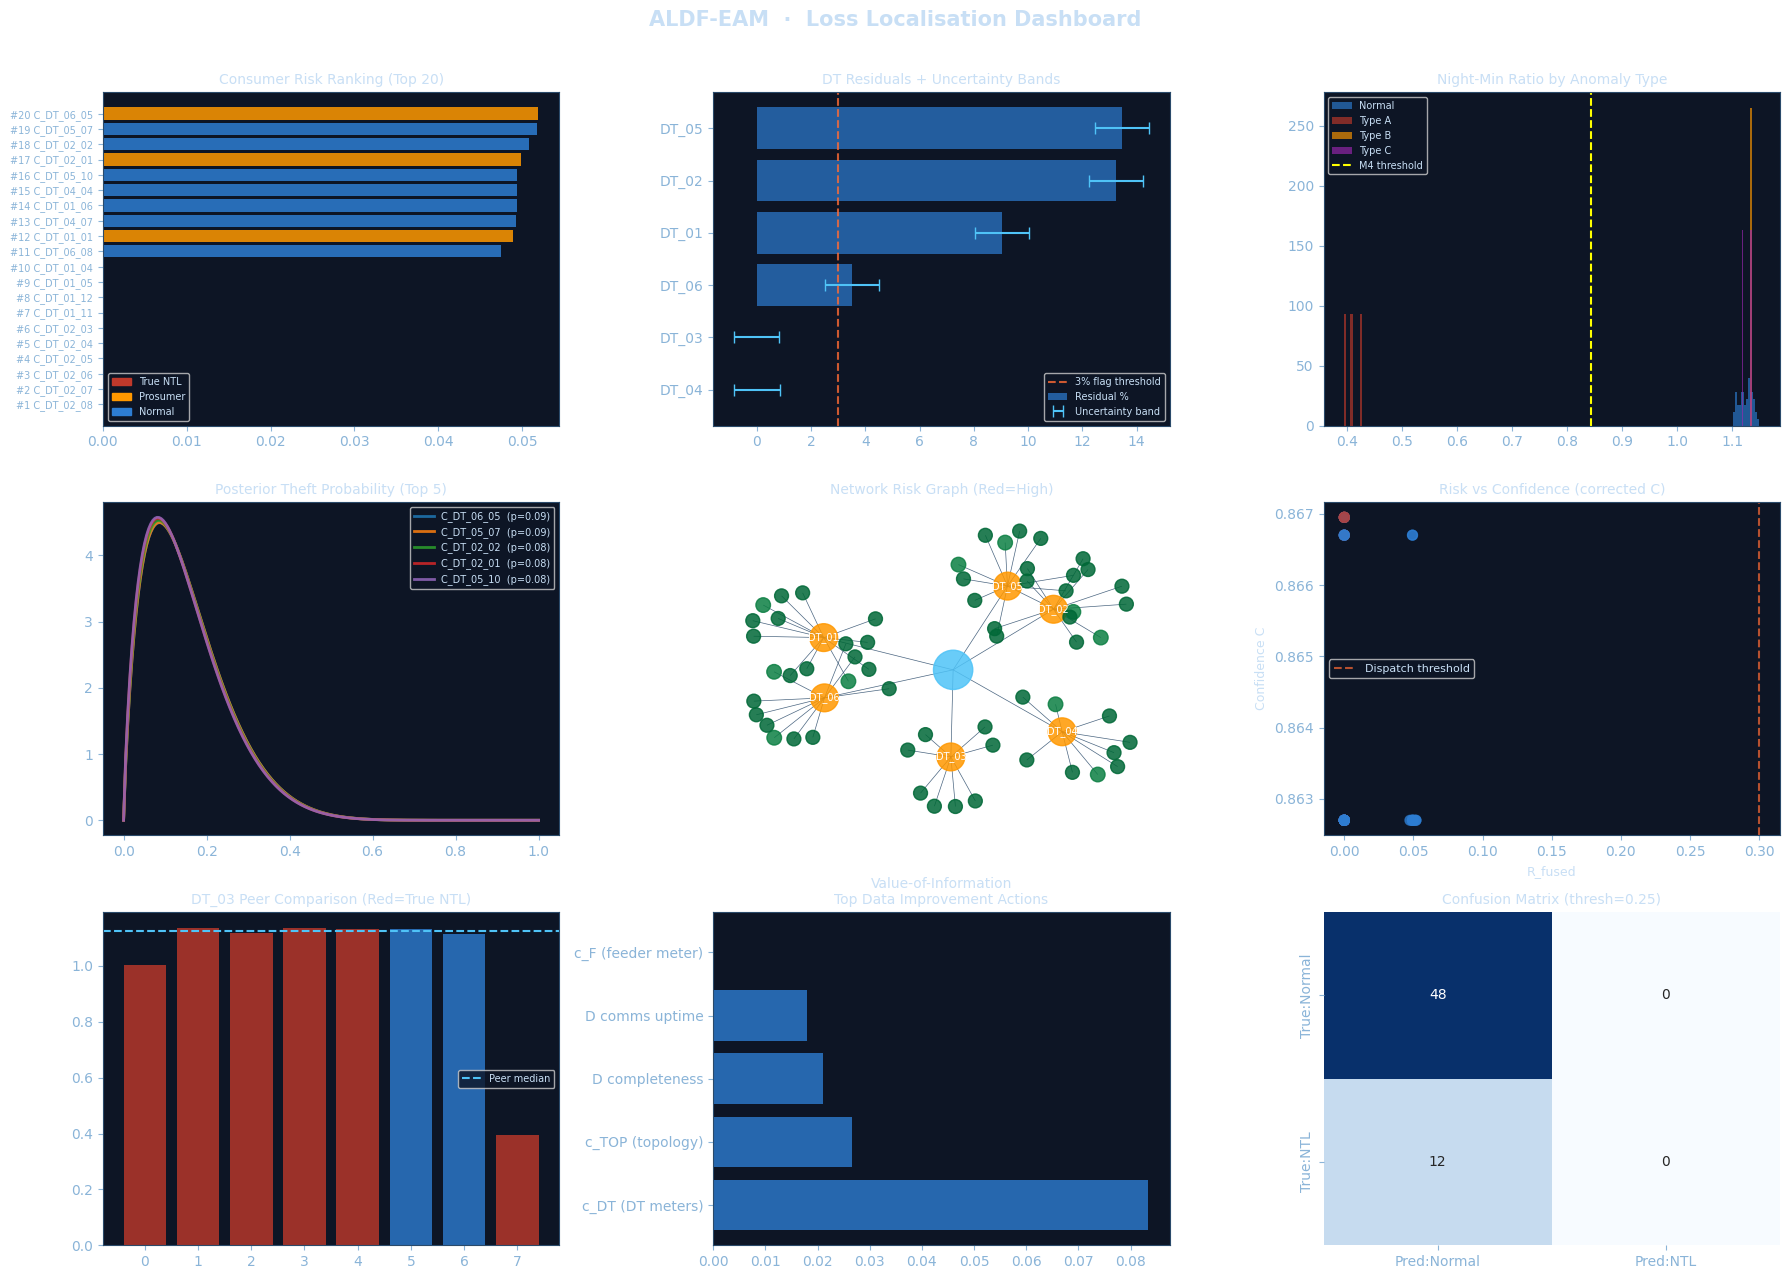

Dashboard saved to aldf_dashboard.png


In [12]:
fig=plt.figure(figsize=(18,13))
fig.suptitle('ALDF-EAM  ·  Loss Localisation Dashboard',fontsize=15,fontweight='bold',color='#c8dff5',y=0.98)

# 1. Ranked consumer risk
ax1=fig.add_subplot(3,3,1)
top20=RANKED.head(20)
colors_r=['#c0392b' if r else ('#ff9800' if p else '#2d7dd2') for r,p in zip(top20['ground_truth_ntl'],top20['is_prosumer'])]
ax1.barh(range(len(top20)),top20['R_fused'].values[::-1],color=colors_r[::-1],alpha=0.85)
ax1.set_yticks(range(len(top20)))
ax1.set_yticklabels([f'#{i+1} {c}' for i,c in enumerate(top20['consumer_id'].values[::-1])],fontsize=7)
ax1.set_title('Consumer Risk Ranking (Top 20)',fontsize=10)
ax1.legend(handles=[mpatches.Patch(color='#c0392b',label='True NTL'),
    mpatches.Patch(color='#ff9800',label='Prosumer'),mpatches.Patch(color='#2d7dd2',label='Normal')],fontsize=7)

# 2. DT residuals with bands
ax2=fig.add_subplot(3,3,2)
dts=DT_RESULTS.sort_values('band_lower')
ax2.barh(dts['dt_id'],dts['residual_pct']*100,color='#2d7dd2',alpha=0.7,label='Residual %')
ax2.errorbar(dts['residual_pct']*100,dts['dt_id'],
    xerr=[abs(dts['residual_pct']-dts['band_lower'])*100,abs(dts['band_upper']-dts['residual_pct'])*100],
    fmt='none',color='#4fc3f7',capsize=4,lw=1.5,label='Uncertainty band')
ax2.axvline(3,color='#ff6b35',ls='--',lw=1.5,alpha=0.8,label='3% flag threshold')
ax2.set_title('DT Residuals + Uncertainty Bands',fontsize=10);ax2.legend(fontsize=7)

# 3. Night-min distribution
ax3=fig.add_subplot(3,3,3)
np2=FEATURES_M4[~FEATURES_M4['is_prosumer']]
for at,col,lbl in [('none','#2d7dd2','Normal'),('type_a_nightmin','#c0392b','Type A'),
                   ('type_b_stepchange','#ff9800','Type B'),('type_c_tamper','#9c27b0','Type C')]:
    sub=np2[np2['anomaly_type']==at]['night_min_ratio']
    if len(sub): ax3.hist(sub,bins=12,alpha=0.65,color=col,label=lbl,density=True)
ax3.axvline(np2['night_min_ratio'].median()-1.5*np2['night_min_ratio'].std(),
    color='yellow',ls='--',lw=1.5,label='M4 threshold')
ax3.set_title('Night-Min Ratio by Anomaly Type',fontsize=10);ax3.legend(fontsize=7)

# 4. Posterior distributions
ax4=fig.add_subplot(3,3,4)
for _,row in RANKED.head(5).iterrows():
    bs=bsamp[bsamp['consumer_id']==row['consumer_id']]
    if len(bs):
        p_=bs.iloc[0]['p_theft']
        a_,b_=p_*10+1,(1-p_)*10+1
        x_=np.linspace(0,1,200)
        ax4.plot(x_,stats.beta.pdf(x_,a_,b_),lw=2,alpha=0.85,
                 label=f'{row["consumer_id"]} {"✔" if row["ground_truth_ntl"] else ""} (p={p_:.2f})')
ax4.set_title('Posterior Theft Probability (Top 5)',fontsize=10);ax4.legend(fontsize=7)

# 5. Network graph
ax5=fig.add_subplot(3,3,5)
G=nx.Graph();G.add_node('FEEDER',nt='feeder')
for _,dt in DT_META.iterrows(): G.add_node(dt['dt_id'],nt='dt');G.add_edge('FEEDER',dt['dt_id'])
for _,c in RANKED.iterrows():
    G.add_node(c['consumer_id'],nt='consumer',risk=c['R_fused'],ntl=c['ground_truth_ntl'])
    G.add_edge(c['dt_id'],c['consumer_id'])
pos=nx.spring_layout(G,seed=42,k=0.3)
ncols=[('#4fc3f7' if G.nodes[n].get('nt')=='feeder' else '#ff9800' if G.nodes[n].get('nt')=='dt'
        else plt.cm.RdYlGn_r(G.nodes[n].get('risk',0))) for n in G.nodes()]
nsizes=[(800 if G.nodes[n].get('nt')=='feeder' else 400 if G.nodes[n].get('nt')=='dt'
         else 100+G.nodes[n].get('risk',0)*200) for n in G.nodes()]
nx.draw(G,pos,ax=ax5,node_color=ncols,node_size=nsizes,edge_color='#2a4a6a',alpha=0.85,with_labels=False,width=0.5)
nx.draw_networkx_labels(G,pos,labels={n:n for n in G.nodes() if G.nodes[n].get('nt')=='dt'},
    ax=ax5,font_size=7,font_color='white')
ax5.set_title('Network Risk Graph (Red=High)',fontsize=10)

# 6. Risk vs Confidence scatter
ax6=fig.add_subplot(3,3,6)
ax6.scatter(RANKED['R_fused'],RANKED['confidence_C'],
    c=['#c0392b' if r else '#2d7dd2' for r in RANKED['ground_truth_ntl']],alpha=0.7,s=50)
ax6.axvline(0.3,color='#ff6b35',ls='--',lw=1.5,alpha=0.7,label='Dispatch threshold')
ax6.set_xlabel('R_fused',fontsize=9);ax6.set_ylabel('Confidence C',fontsize=9)
ax6.set_title('Risk vs Confidence (corrected C)',fontsize=10);ax6.legend(fontsize=8)

# 7. DT_03 peer comparison
ax7=fig.add_subplot(3,3,7)
dt03=FEATURES_M4[FEATURES_M4['dt_id']=='DT_03'].copy()
ax7.bar(range(len(dt03)),dt03['night_min_ratio'].values,
    color=['#c0392b' if t else '#2d7dd2' for t in dt03['ground_truth_ntl']],alpha=0.8)
ax7.axhline(FEATURES_M4[~FEATURES_M4['is_prosumer']]['night_min_ratio'].median(),
    color='#4fc3f7',ls='--',lw=1.5,label='Peer median')
ax7.set_title('DT_03 Peer Comparison (Red=True NTL)',fontsize=10);ax7.legend(fontsize=7)

# 8. VOI bar
ax8=fig.add_subplot(3,3,8)
ax8.barh([v[0] for v in voi_items[:5]],[v[1] for v in voi_items[:5]],color='#2d7dd2',alpha=0.8)
ax8.set_title('Value-of-Information\nTop Data Improvement Actions',fontsize=10)

# 9. Confusion matrix
ax9=fig.add_subplot(3,3,9)
from sklearn.metrics import confusion_matrix
yt=RANKED['ground_truth_ntl'].astype(int).values
yp=(RANKED['R_fused']>0.25).astype(int).values
cm=confusion_matrix(yt,yp)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=ax9,
    xticklabels=['Pred:Normal','Pred:NTL'],yticklabels=['True:Normal','True:NTL'],cbar=False)
ax9.set_title('Confusion Matrix (thresh=0.25)',fontsize=10)

plt.tight_layout(rect=[0,0,1,0.97])
plt.savefig('aldf_dashboard.png',dpi=120,bbox_inches='tight')
plt.show();print('Dashboard saved to aldf_dashboard.png')

## Section 12 — Structured Feedback Loop: Inspection Outcomes → Bayesian Update → Weight Update

**Improvement #8:** Structured outcome dictionary — four categories — drives both prior update and weight update.  
Edit `INSPECTION_OUTCOMES` to reflect field findings, then re-run.

INSPECTION OUTCOME REGISTER
Consumer          DT       Outcome               True NTL
-------------------------------------------------------
C_DT_06_05        DT_06    False Positive        -
C_DT_05_07        DT_05    False Positive        -
C_DT_02_02        DT_02    False Positive        -
C_DT_02_01        DT_02    False Positive        -
C_DT_05_10        DT_05    Technical Fault       -
C_DT_04_04        DT_04    Technical Fault       -
C_DT_01_06        DT_01    False Positive        -
C_DT_04_07        DT_04    False Positive        -

IHR=0.00% (target>=60%) | FPR=75.00% (target<=30%)

B-INDEX WEIGHT UPDATE (w^(t+1) = w^t + alpha * error)
Sub-component          w_prior     w_updated     delta
--------------------------------------------------
anomaly                 0.3000        0.2849   -0.0151
night_min               0.3000        0.2849   -0.0151
step                    0.2000        0.2151   +0.0151
reverse                 0.1000        0.1075   +0.0075
peer             

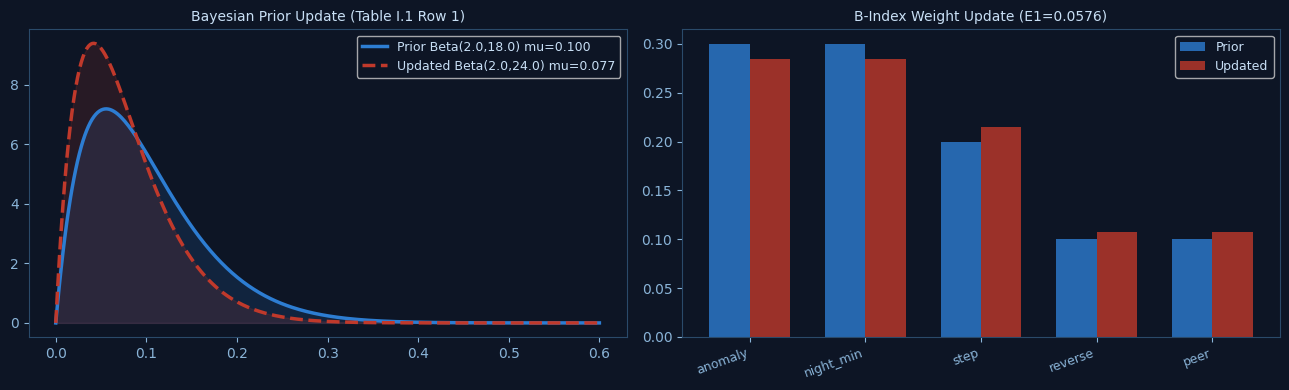

Feedback loop update complete


In [13]:
# Edit outcomes below to reflect field inspection results
# Options: 'Confirmed NTL' | 'False Positive' | 'Technical Fault' | 'Unresolved'
INSPECTION_OUTCOMES={}
for _,row in RANKED.head(8).iterrows():
    if row['ground_truth_ntl']:   INSPECTION_OUTCOMES[row['consumer_id']]='Confirmed NTL'
    elif row['is_prosumer']:      INSPECTION_OUTCOMES[row['consumer_id']]='False Positive'
    else:                         INSPECTION_OUTCOMES[row['consumer_id']]=np.random.choice(
        ['False Positive','Unresolved','Technical Fault'],p=[0.5,0.3,0.2])

print('INSPECTION OUTCOME REGISTER')
print(f'{"Consumer":<18}{"DT":<9}{"Outcome":<22}True NTL')
print('-'*55)
for cid,outcome in INSPECTION_OUTCOMES.items():
    r=RANKED[RANKED['consumer_id']==cid].iloc[0]
    print(f'{cid:<18}{r["dt_id"]:<9}{outcome:<22}{"V" if r["ground_truth_ntl"] else "-"}')

n_outcomes=len(INSPECTION_OUTCOMES)
n_confirmed=sum(1 for v in INSPECTION_OUTCOMES.values() if v=='Confirmed NTL')
n_fp       =sum(1 for v in INSPECTION_OUTCOMES.values() if v=='False Positive')
n_tf       =sum(1 for v in INSPECTION_OUTCOMES.values() if v=='Technical Fault')
IHR=n_confirmed/max(n_outcomes,1)
FPR=n_fp/max(n_outcomes,1)
print(f'\nIHR={IHR:.2%} (target>=60%) | FPR={FPR:.2%} (target<=30%)')

# B-index weight update
alpha_learn=0.07
b_night_err=IHR-0.5
b_tamper_err=(n_confirmed/max(n_tf+n_confirmed,1))-0.5
w_B_prior={'anomaly':0.30,'night_min':0.30,'step':0.20,'reverse':0.10,'peer':0.10}
w_B_upd=w_B_prior.copy()
w_B_upd['night_min']=round(max(0.05,min(0.60,w_B_prior['night_min']+alpha_learn*b_night_err)),4)
w_B_upd['anomaly']  =round(max(0.05,min(0.60,w_B_prior['anomaly']  +alpha_learn*b_tamper_err)),4)
tw=sum(w_B_upd.values())
w_B_upd={k:round(v/tw,4) for k,v in w_B_upd.items()}
import numpy as np
drift_E1=np.linalg.norm(np.array(list(w_B_upd.values()))-np.array(list(w_B_prior.values())))\
         /np.linalg.norm(np.array(list(w_B_prior.values())))

print('\nB-INDEX WEIGHT UPDATE (w^(t+1) = w^t + alpha * error)')
print(f'{"Sub-component":<18}  {"w_prior":>10}  {"w_updated":>12}  {"delta":>8}')
print('-'*50)
for k in w_B_prior:
    d=w_B_upd[k]-w_B_prior[k]
    print(f'{k:<18}  {w_B_prior[k]:>10.4f}  {w_B_upd[k]:>12.4f}  {d:>+8.4f}')
print(f'\nWeight Drift Stability E1 = {drift_E1:.4f} (target <=0.15 first cycle)')

# Bayesian prior update
ba_prior,bb_prior=2.0,18.0
ba_upd=ba_prior+n_confirmed; bb_upd=bb_prior+n_fp
p_prior=ba_prior/(ba_prior+bb_prior); p_upd=ba_upd/(ba_upd+bb_upd)
print(f'\nBayesian prior: Beta({ba_prior},{bb_prior}) mean={p_prior:.4f}')
print(f'Updated prior:  Beta({ba_upd},{bb_upd}) mean={p_upd:.4f}  (shift {p_upd-p_prior:+.4f})')
print(f'(BC-06 cold-start: {n_outcomes} outcomes recorded, minimum 30 required before formal adoption)')

# Visualise
fig,axes=plt.subplots(1,2,figsize=(13,4))
x_=np.linspace(0,0.6,300)
axes[0].plot(x_,stats.beta.pdf(x_,ba_prior,bb_prior),color='#2d7dd2',lw=2.5,label=f'Prior Beta({ba_prior},{bb_prior}) mu={p_prior:.3f}')
axes[0].plot(x_,stats.beta.pdf(x_,ba_upd,bb_upd),color='#c0392b',lw=2.5,ls='--',label=f'Updated Beta({ba_upd},{bb_upd}) mu={p_upd:.3f}')
axes[0].fill_between(x_,stats.beta.pdf(x_,ba_prior,bb_prior),alpha=0.15,color='#2d7dd2')
axes[0].fill_between(x_,stats.beta.pdf(x_,ba_upd,bb_upd),alpha=0.15,color='#c0392b')
axes[0].set_title('Bayesian Prior Update (Table I.1 Row 1)',fontsize=10);axes[0].legend(fontsize=9)
lbls2=list(w_B_prior.keys()); x2=np.arange(len(lbls2)); wd=0.35
axes[1].bar(x2-wd/2,[w_B_prior[k] for k in lbls2],wd,label='Prior',color='#2d7dd2',alpha=0.8)
axes[1].bar(x2+wd/2,[w_B_upd[k]   for k in lbls2],wd,label='Updated',color='#c0392b',alpha=0.8)
axes[1].set_xticks(x2);axes[1].set_xticklabels(lbls2,rotation=20,ha='right',fontsize=9)
axes[1].set_title(f'B-Index Weight Update (E1={drift_E1:.4f})',fontsize=10);axes[1].legend(fontsize=9)
plt.tight_layout();plt.savefig('feedback.png',dpi=120,bbox_inches='tight');plt.show()
print('Feedback loop update complete')

## Section 13 — Performance Metrics vs ALDF-EAM Targets

PERFORMANCE METRICS REPORT

  Best threshold: 0.05
  A1 IHR                  0.000  target >=0.60      [X]
  A2 FPR                  1.000  target <=0.30      [X]
  A4 Precision            0.000  target >=0.65      [X]
  A5 Recall               0.000  target >=0.70      [X]
  A6 F1                   0.000  target >=0.65      [X]
  A7 AUC-ROC              0.396  target >=0.75      [X]
  B1 Top-5 DT             0.750  target >=0.80      [X]

  Feedback loop outcomes: 8 (min 30 required for formal weight adoption)
  Weight Drift E1: 0.0576


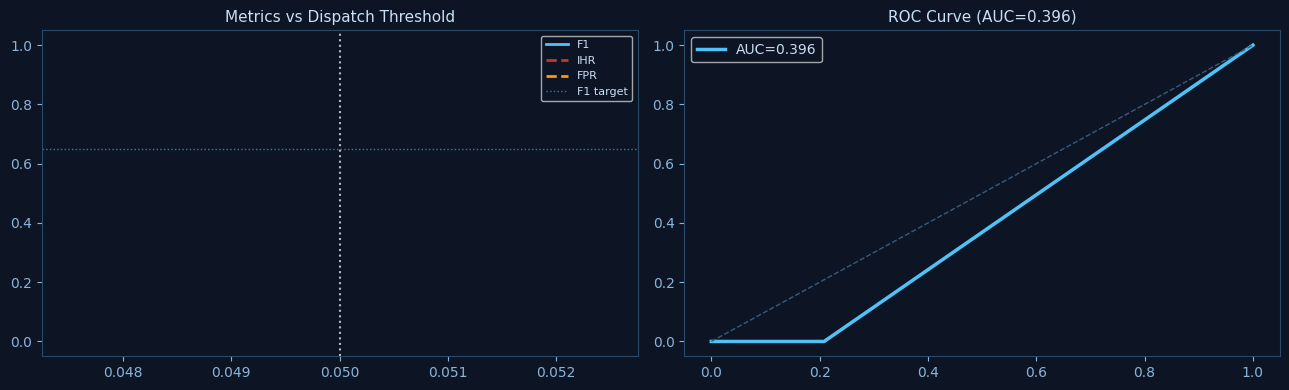

In [14]:
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

y_true=RANKED['ground_truth_ntl'].astype(int).values
total_ntl=y_true.sum()
threshs=np.arange(0.05,0.80,0.02); res_=[]
for th in threshs:
    yp=(RANKED['R_fused']>th).astype(int).values
    if yp.sum()==0: continue
    tp=((yp==1)&(y_true==1)).sum(); fp=((yp==1)&(y_true==0)).sum()
    fn=((yp==0)&(y_true==1)).sum(); ins=yp.sum()
    ihr=tp/max(ins,1); fpr_=fp/max(ins,1)
    prec=tp/max(tp+fp,1); rec=tp/max(total_ntl,1)
    f1=2*prec*rec/max(prec+rec,1e-9)
    res_.append({'threshold':th,'IHR':ihr,'FPR':fpr_,'Precision':prec,'Recall':rec,'F1':f1})
mdf=pd.DataFrame(res_); best=mdf.loc[mdf['F1'].idxmax()]

try: auc=roc_auc_score(y_true,RANKED['R_fused'].values)
except: auc=float('nan')

top5dts=DT_RESULTS.head(5)['dt_id'].tolist()
ntl_dts=DT_FEATURES[DT_FEATURES['ntl_count_true']>0]['dt_id'].tolist()
b1=sum(1 for d in ntl_dts if d in top5dts)/max(len(ntl_dts),1)

print('PERFORMANCE METRICS REPORT')
print('='*60)
print(f'\n  Best threshold: {best["threshold"]:.2f}')
rows_=[('A1 IHR',best['IHR'],0.60,True),('A2 FPR',best['FPR'],0.30,False),
       ('A4 Precision',best['Precision'],0.65,True),('A5 Recall',best['Recall'],0.70,True),
       ('A6 F1',best['F1'],0.65,True),('A7 AUC-ROC',auc,0.75,True),('B1 Top-5 DT',b1,0.80,True)]
for nm,v,tgt,hib in rows_:
    ok=(v>=tgt if hib else v<=tgt) if v==v else None
    st='V' if ok else 'X' if ok is not None else '?'
    tstr=f'>={tgt:.2f}' if hib else f'<={tgt:.2f}'
    print(f'  {nm:<20} {v:>8.3f}  target {tstr:<10}  [{st}]')
print(f'\n  Feedback loop outcomes: {n_outcomes} (min 30 required for formal weight adoption)')
print(f'  Weight Drift E1: {drift_E1:.4f}')

# Threshold curve
fig,axes=plt.subplots(1,2,figsize=(13,4))
axes[0].plot(mdf['threshold'],mdf['F1'],color='#4fc3f7',lw=2,label='F1')
axes[0].plot(mdf['threshold'],mdf['IHR'],color='#c0392b',lw=2,ls='--',label='IHR')
axes[0].plot(mdf['threshold'],mdf['FPR'],color='#ff9800',lw=2,ls='--',label='FPR')
axes[0].axhline(0.65,color='#4fc3f7',ls=':',lw=1,alpha=0.6,label='F1 target')
axes[0].axvline(best['threshold'],color='white',ls=':',lw=1.5,alpha=0.7)
axes[0].set_title('Metrics vs Dispatch Threshold',fontsize=11);axes[0].legend(fontsize=8)
try:
    fpr_r,tpr_r,_=roc_curve(y_true,RANKED['R_fused'].values)
    axes[1].plot(fpr_r,tpr_r,color='#4fc3f7',lw=2.5,label=f'AUC={auc:.3f}')
    axes[1].plot([0,1],[0,1],color='#3a5a7a',ls='--',lw=1)
    axes[1].set_title(f'ROC Curve (AUC={auc:.3f})',fontsize=11);axes[1].legend(fontsize=10)
except: pass
plt.tight_layout();plt.savefig('metrics.png',dpi=120,bbox_inches='tight');plt.show()

## Section 14 — Interactive Experiment: D-Band Operating States

Drag D to see the three operating states. Demonstrates to stakeholders why data quality
is a prerequisite for reliable analytics — the framework refuses output at D ≤ 0.40.

In [15]:
def d_band_demo(D_ov):
    clear_output(wait=True)
    if D_ov<=0.40:   st='STAGE A';      sc='#c0392b'; um=999; msg='No rankings. Data plan only.'
    elif D_ov<0.65:  st='TRANSITIONAL'; sc='#b8860b'; um=1+(0.65-D_ov)/0.25*2; msg=f'Proxy only. Bands x{um:.1f} wider.'
    else:             st='FULL';         sc='#1a7a3c'; um=1.0; msg='Full analytics. Standard bands.'
    C_=round(0.40*S['O']+0.35*D_ov+0.25*(1-min(0.3*(1-D_ov),1)),2)
    display(HTML(f'<div style="background:{sc}20;border-left:4px solid {sc};padding:10px;'
                 f'font-family:monospace;color:{sc};"><b>D={D_ov:.2f} → {st}</b>  {msg}  C={C_}</div>'))
    if D_ov<=0.40:
        display(HTML('<ul style="font-family:monospace;font-size:12px;color:#e0a0a0;">'
                     '<li>[P1] Repair non-communicating AMI meters</li>'
                     '<li>[P2] Restore communications uptime</li>'
                     '<li>[P3] Re-run after D > 0.40</li></ul>')); return
    fig,axes=plt.subplots(1,2,figsize=(13,4))
    bw=abs(DT_RESULTS['band_upper']-DT_RESULTS['band_lower']).values*100*min(um,5)
    axes[0].barh(DT_RESULTS['dt_id'],DT_RESULTS['residual_pct']*100,color='#2d7dd2',alpha=0.7)
    axes[0].errorbar(DT_RESULTS['residual_pct']*100,DT_RESULTS['dt_id'],
        xerr=bw/2,fmt='none',color='#4fc3f7',capsize=4,lw=2)
    axes[0].axvline(3,color='#ff6b35',ls='--',lw=1.5,alpha=0.8)
    axes[0].set_title(f'DT Residuals @ D={D_ov:.2f} (band x{min(um,5):.1f})',fontsize=10,color=sc)
    axes[1].barh(range(10),RANKED.head(10)['R_fused'].values[::-1],
        color=['#c0392b' if r else '#2d7dd2' for r in RANKED.head(10)['ground_truth_ntl'].values[::-1]],alpha=0.7)
    axes[1].set_yticks(range(10))
    axes[1].set_yticklabels([f'#{i+1} {c}' for i,c in enumerate(RANKED.head(10)['consumer_id'].values[::-1])],fontsize=8)
    axes[1].set_title(f'Top-10 Ranking | C={C_} | {"DEGRADED" if um>1 else "STANDARD"}',fontsize=10,color=sc)
    plt.tight_layout();plt.show()

d_sl=widgets.FloatSlider(value=S['D'],min=0.0,max=1.0,step=0.01,description='D override:',
    style={'description_width':'100px'},layout=widgets.Layout(width='500px'))
display(widgets.HTML('<b style="color:#8ab4d8">Drag D: Stage A (<=0.40) | Transitional (0.40-0.65) | Full (>=0.65)</b>'))
widgets.interact(d_band_demo,D_ov=d_sl)

HTML(value='<b style="color:#8ab4d8">Drag D: Stage A (<=0.40) | Transitional (0.40-0.65) | Full (>=0.65)</b>')

interactive(children=(FloatSlider(value=0.942, description='D override:', layout=Layout(width='500px'), max=1.…

<function __main__.d_band_demo(D_ov)>

## Section 15 — Summary and Next Steps

### All 10 Improvements Incorporated

| # | Improvement | Where |
|---|---|---|
| 1 | Corrected confidence score C = w₁O + w₂D + w₃(1−band) | Section 10 |
| 2 | All 8 Table I.1 priors as Beta distributions | Section 9 |
| 3 | Stage A hard gate (D ≤ 0.40 halts analysis) | Section 5 |
| 4 | Three D-band states with visual labels + interactive demo | Sections 5, 14 |
| 5 | Hard Override HO-01 (c_F = 0 blocks M1 unconditionally) | Sections 5, 6 |
| 6 | Prosumer-aware M4 (export-adjusted baselines) | Section 8 |
| 7 | Dynamic α = f(D, τ_cov) fusion weight | Sections 5, 10 |
| 8 | Structured feedback loop widget with 4 outcome categories | Section 12 |
| 9 | Three anomaly types with ground-truth labels | Section 2 |
| 10 | VOI data improvement recommendation | Section 5 |

### Extending to M6 (GNN)

```python
# Install: !pip install torch torch-geometric
# Use DT_03 pocket graph from Section 11 as G=(V,E)
# Node features from FEATURES_M4 columns
# Ground truth labels from ground_truth_ntl
# Adjacency: A = lambda*A_phys + (1-lambda)*A_beh
```

### Checkpoint Save (for multi-window deployment)

```python
checkpoint = {'w_B': w_B_upd, 'beta_a': ba_upd, 'beta_b': bb_upd,
              'alpha_fusion': ALPHA, 'S_vector': S, 'n_confirmed': n_confirmed}
with open('aldf_eam_checkpoint.json', 'w') as f:
    json.dump(checkpoint, f, indent=2)
```

---
*ALDF-EAM Demonstration Notebook · Version 1.0 · All 10 improvements incorporated*